In [1]:
import pandas as pd

from src.predictive_modeling.answer_correctness.models.logreg_model import TrialLevelLogRegModel
from src.predictive_modeling.answer_correctness.cross_validation import (
    run_cross_validation_on_predefined_folds,
    show_cv_results,
    plot_cv_metric_by_regime_pretty,
)

import src.constants as Con
from src.data_paths import (
    GATHERERS_FOLDS_DIR,
    HUNTERS_FOLDS_DIR,
    GATHERERS_PROCESSED_PATH,
    HUNTERS_PROCESSED_PATH,
)

In [2]:
hunters = pd.read_csv(HUNTERS_PROCESSED_PATH)
gatherers = pd.read_csv(GATHERERS_PROCESSED_PATH)

In [3]:
SELECTED_METRIC_COLUMNS = [
        Con.SKIP_RATE,
        Con.AREA_DWELL_PROPORTION,
        Con.NUM_LABEL_VISITS,
]

SELECTED_COLS = (
    [f"{m}__correct" for m in SELECTED_METRIC_COLUMNS] +
    [f"{m}__wrong_mean" for m in SELECTED_METRIC_COLUMNS] +
    [
    "seq_len",
    "has_xyx",
    ]
)

In [4]:
cv_out_gatherers = run_cross_validation_on_predefined_folds(
    df=gatherers,
    fold_dir=GATHERERS_FOLDS_DIR,
    model_builders={
        "full_features_correctness_log_reg": lambda: TrialLevelLogRegModel(),
    },
    target_col=Con.IS_CORRECT_COLUMN,
    n_folds=10,
    df_participant_col=Con.PARTICIPANT_ID,
    df_text_col=Con.TEXT_ID_COLUMN,
    feature_cols_by_model={
        "full_features_correctness_log_reg": SELECTED_COLS,
    },
)

In [5]:
print("### GATHERERS ###")
cv_tables_gatherers = show_cv_results(cv_out_gatherers)

### GATHERERS ###
CROSS-VALIDATION RESULTS: full_features_correctness_log_reg

1) Fold-level raw results


,model,fold,regime,accuracy,balanced_accuracy,n_eval,n_positive,n_negative
0,full_features_correctness_log_reg,0,test_seen_subject_unseen_item,0.807407,0.757284,1080,912,168
1,full_features_correctness_log_reg,1,test_seen_subject_unseen_item,0.808445,0.804595,971,807,164
2,full_features_correctness_log_reg,2,test_seen_subject_unseen_item,0.787392,0.778937,809,668,141
3,full_features_correctness_log_reg,3,test_seen_subject_unseen_item,0.774074,0.748842,810,659,151
4,full_features_correctness_log_reg,4,test_seen_subject_unseen_item,0.737473,0.756042,918,697,221
5,full_features_correctness_log_reg,5,test_seen_subject_unseen_item,0.804843,0.804857,702,579,123
6,full_features_correctness_log_reg,6,test_seen_subject_unseen_item,0.798765,0.793720,810,647,163
7,full_features_correctness_log_reg,7,test_seen_subject_unseen_item,0.753561,0.781460,702,548,154
8,full_features_correctness_log_reg,8,test_seen_subject_unseen_item,0.764774,0.767571,863,656,207
9,full_features_correctness_log_reg,9,test_seen_subject_unseen_item,0.760185,0.782318,1080,936,144



2) Aggregated by regime (balanced_accuracy)


,regime,n_folds,mean_metric,std_metric,min_metric,max_metric,mean_n_eval,total_n_eval,se_metric,ci_low,ci_high,metric
0,test_seen_subject_unseen_item,10,0.777563,0.019932,0.748842,0.804857,874.5,8745,0.006303,0.765209,0.789917,balanced_accuracy
1,test_unseen_subject_seen_item,10,0.776066,0.017066,0.751860,0.801624,874.5,8745,0.005397,0.765488,0.786644,balanced_accuracy
2,test_unseen_subject_unseen_item,10,0.745105,0.082108,0.581781,0.833333,97.2,972,0.025965,0.694214,0.795996,balanced_accuracy
3,val_seen_subject_unseen_item,10,0.772859,0.018662,0.749383,0.800415,777.3,7773,0.005902,0.761292,0.784426,balanced_accuracy
4,val_unseen_subject_seen_item,10,0.776405,0.019434,0.751325,0.800434,777.3,7773,0.006146,0.764360,0.788451,balanced_accuracy
5,val_unseen_subject_unseen_item,10,0.735087,0.077921,0.609717,0.822013,97.2,972,0.024641,0.686791,0.783383,balanced_accuracy



3) Test-only regimes (balanced_accuracy)


,regime,n_folds,mean_metric,std_metric,min_metric,max_metric,mean_n_eval,total_n_eval,se_metric,ci_low,ci_high,metric
0,test_seen_subject_unseen_item,10,0.777563,0.019932,0.748842,0.804857,874.5,8745,0.006303,0.765209,0.789917,balanced_accuracy
1,test_unseen_subject_seen_item,10,0.776066,0.017066,0.751860,0.801624,874.5,8745,0.005397,0.765488,0.786644,balanced_accuracy
2,test_unseen_subject_unseen_item,10,0.745105,0.082108,0.581781,0.833333,97.2,972,0.025965,0.694214,0.795996,balanced_accuracy



4) Validation-only regimes (balanced_accuracy)


,regime,n_folds,mean_metric,std_metric,min_metric,max_metric,mean_n_eval,total_n_eval,se_metric,ci_low,ci_high,metric
0,val_seen_subject_unseen_item,10,0.772859,0.018662,0.749383,0.800415,777.3,7773,0.005902,0.761292,0.784426,balanced_accuracy
1,val_unseen_subject_seen_item,10,0.776405,0.019434,0.751325,0.800434,777.3,7773,0.006146,0.764360,0.788451,balanced_accuracy
2,val_unseen_subject_unseen_item,10,0.735087,0.077921,0.609717,0.822013,97.2,972,0.024641,0.686791,0.783383,balanced_accuracy



5) Overall mean across all fold-regime evaluations (balanced_accuracy)


,model,metric,n_rows,n_folds,mean_metric,std_metric,min_metric,max_metric,total_n_eval
0,full_features_correctness_log_reg,balanced_accuracy,60,10,0.763848,0.049677,0.581781,0.833333,34980


,regime,n_folds,mean_metric,std_metric,min_metric,max_metric,mean_n_eval,total_n_eval,se_metric,ci_low,ci_high,metric
0,test_seen_subject_unseen_item,10,0.779692,0.025277,0.737473,0.808445,874.5,8745,0.007993,0.764025,0.795359,accuracy
1,test_unseen_subject_seen_item,10,0.778095,0.022792,0.737629,0.810658,874.5,8745,0.007207,0.763968,0.792221,accuracy
2,test_unseen_subject_unseen_item,10,0.763131,0.037133,0.708333,0.833333,97.2,972,0.011742,0.740115,0.786146,accuracy
3,val_seen_subject_unseen_item,10,0.778505,0.022471,0.742647,0.806250,777.3,7773,0.007106,0.764578,0.792433,accuracy
4,val_unseen_subject_seen_item,10,0.778001,0.021018,0.740834,0.802005,777.3,7773,0.006646,0.764974,0.791028,accuracy
5,val_unseen_subject_unseen_item,10,0.755752,0.036733,0.708333,0.816667,97.2,972,0.011616,0.732985,0.778519,accuracy


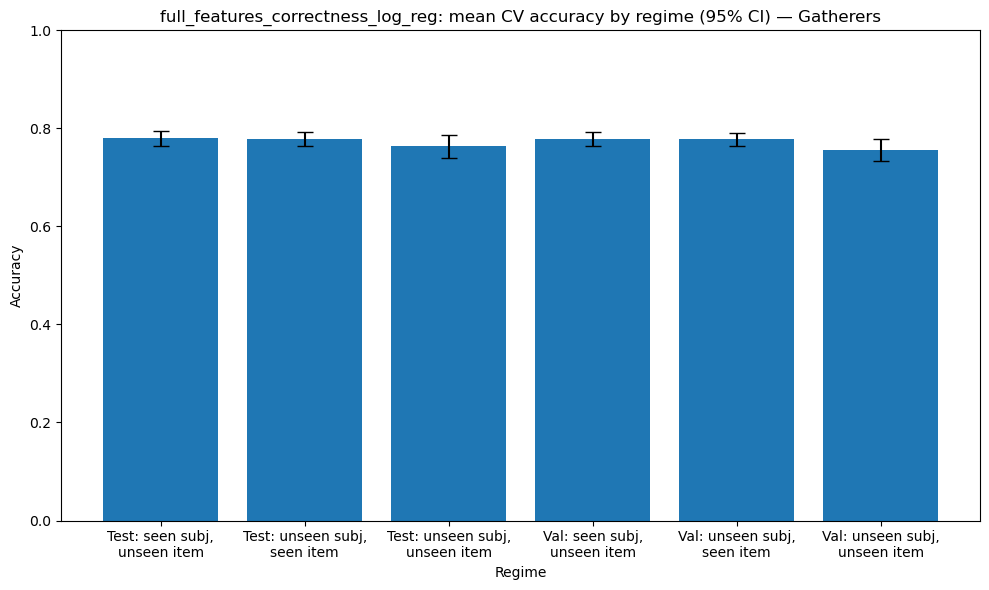

In [6]:
cv_regime_summary_gatherers, fig, ax = plot_cv_metric_by_regime_pretty(
    cv_out_gatherers,
    metric_col="accuracy",
)
ax.set_title(ax.get_title() + " — Gatherers")
display(cv_regime_summary_gatherers)

In [7]:
cv_out_hunters = run_cross_validation_on_predefined_folds(
    df=hunters,
    fold_dir=HUNTERS_FOLDS_DIR,
    model_builders={
        "full_features_correctness_log_reg": lambda: TrialLevelLogRegModel(),
    },
    target_col=Con.IS_CORRECT_COLUMN,
    n_folds=10,
    df_participant_col=Con.PARTICIPANT_ID,
    df_text_col=Con.TEXT_ID_COLUMN,
    feature_cols_by_model={
        "full_features_correctness_log_reg": SELECTED_COLS,
    },
)

In [8]:
print("### HUNTERS ###")
cv_tables_hunters = show_cv_results(cv_out_hunters)

### HUNTERS ###
CROSS-VALIDATION RESULTS: full_features_correctness_log_reg

1) Fold-level raw results


,model,fold,regime,accuracy,balanced_accuracy,n_eval,n_positive,n_negative
0,full_features_correctness_log_reg,0,test_seen_subject_unseen_item,0.787766,0.776364,1079,945,134
1,full_features_correctness_log_reg,1,test_seen_subject_unseen_item,0.776749,0.775889,972,861,111
2,full_features_correctness_log_reg,2,test_seen_subject_unseen_item,0.787582,0.803428,918,780,138
3,full_features_correctness_log_reg,3,test_seen_subject_unseen_item,0.801235,0.770065,810,700,110
4,full_features_correctness_log_reg,4,test_seen_subject_unseen_item,0.746439,0.763407,702,618,84
5,full_features_correctness_log_reg,5,test_seen_subject_unseen_item,0.792023,0.795310,702,597,105
6,full_features_correctness_log_reg,6,test_seen_subject_unseen_item,0.769231,0.754605,702,586,116
7,full_features_correctness_log_reg,7,test_seen_subject_unseen_item,0.812757,0.786483,972,836,136
8,full_features_correctness_log_reg,8,test_seen_subject_unseen_item,0.801235,0.797853,810,718,92
9,full_features_correctness_log_reg,9,test_seen_subject_unseen_item,0.749074,0.779878,1080,958,122



2) Aggregated by regime (balanced_accuracy)


,regime,n_folds,mean_metric,std_metric,min_metric,max_metric,mean_n_eval,total_n_eval,se_metric,ci_low,ci_high,metric
0,test_seen_subject_unseen_item,10,0.780328,0.015606,0.754605,0.803428,874.7,8747,0.004935,0.770655,0.790001,balanced_accuracy
1,test_unseen_subject_seen_item,10,0.776321,0.028125,0.699853,0.795060,874.7,8747,0.008894,0.758889,0.793753,balanced_accuracy
2,test_unseen_subject_unseen_item,10,0.756695,0.093341,0.625362,0.857531,97.2,972,0.029517,0.698842,0.814549,balanced_accuracy
3,val_seen_subject_unseen_item,10,0.780110,0.020489,0.747316,0.802909,777.5,7775,0.006479,0.767410,0.792809,balanced_accuracy
4,val_unseen_subject_seen_item,10,0.780277,0.028811,0.705138,0.807937,777.5,7775,0.009111,0.762420,0.798134,balanced_accuracy
5,val_unseen_subject_unseen_item,10,0.753561,0.103310,0.595950,0.859226,97.2,972,0.032669,0.689529,0.817593,balanced_accuracy



3) Test-only regimes (balanced_accuracy)


,regime,n_folds,mean_metric,std_metric,min_metric,max_metric,mean_n_eval,total_n_eval,se_metric,ci_low,ci_high,metric
0,test_seen_subject_unseen_item,10,0.780328,0.015606,0.754605,0.803428,874.7,8747,0.004935,0.770655,0.790001,balanced_accuracy
1,test_unseen_subject_seen_item,10,0.776321,0.028125,0.699853,0.795060,874.7,8747,0.008894,0.758889,0.793753,balanced_accuracy
2,test_unseen_subject_unseen_item,10,0.756695,0.093341,0.625362,0.857531,97.2,972,0.029517,0.698842,0.814549,balanced_accuracy



4) Validation-only regimes (balanced_accuracy)


,regime,n_folds,mean_metric,std_metric,min_metric,max_metric,mean_n_eval,total_n_eval,se_metric,ci_low,ci_high,metric
0,val_seen_subject_unseen_item,10,0.780110,0.020489,0.747316,0.802909,777.5,7775,0.006479,0.767410,0.792809,balanced_accuracy
1,val_unseen_subject_seen_item,10,0.780277,0.028811,0.705138,0.807937,777.5,7775,0.009111,0.762420,0.798134,balanced_accuracy
2,val_unseen_subject_unseen_item,10,0.753561,0.103310,0.595950,0.859226,97.2,972,0.032669,0.689529,0.817593,balanced_accuracy



5) Overall mean across all fold-regime evaluations (balanced_accuracy)


,model,metric,n_rows,n_folds,mean_metric,std_metric,min_metric,max_metric,total_n_eval
0,full_features_correctness_log_reg,balanced_accuracy,60,10,0.771215,0.058651,0.59595,0.859226,34988


,regime,n_folds,mean_metric,std_metric,min_metric,max_metric,mean_n_eval,total_n_eval,se_metric,ci_low,ci_high,metric
0,test_seen_subject_unseen_item,10,0.782409,0.022082,0.746439,0.812757,874.7,8747,0.006983,0.768723,0.796095,accuracy
1,test_unseen_subject_seen_item,10,0.778654,0.024587,0.734177,0.812207,874.7,8747,0.007775,0.763415,0.793894,accuracy
2,test_unseen_subject_unseen_item,10,0.784682,0.053628,0.679487,0.861111,97.2,972,0.016959,0.751443,0.817921,accuracy
3,val_seen_subject_unseen_item,10,0.781894,0.025221,0.730769,0.818287,777.5,7775,0.007976,0.766262,0.797527,accuracy
4,val_unseen_subject_seen_item,10,0.783255,0.021871,0.748395,0.811828,777.5,7775,0.006916,0.769699,0.796811,accuracy
5,val_unseen_subject_unseen_item,10,0.784288,0.055981,0.666667,0.851852,97.2,972,0.017703,0.749591,0.818986,accuracy


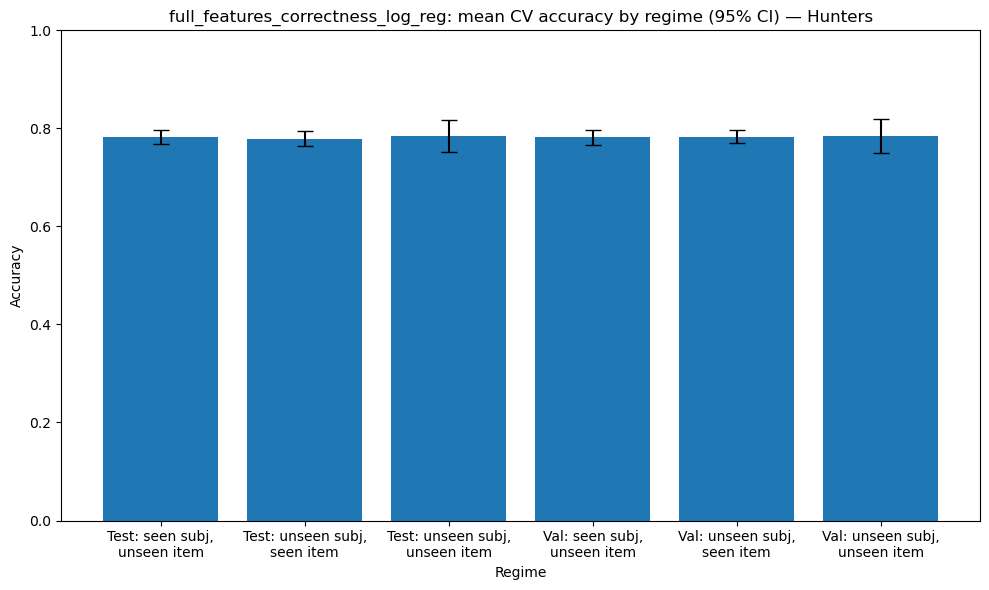

In [9]:
cv_regime_summary_hunters, fig, ax = plot_cv_metric_by_regime_pretty(
    cv_out_hunters,
    metric_col="accuracy",
)
ax.set_title(ax.get_title() + " — Hunters")
display(cv_regime_summary_hunters)